# Module 4: Deep Learning on Azure LLM Inference VM Traces
### Author: Kirk Kennedy Lincoln

Dataset: Azure LLM Inference from https://azurepublicdatasettraces.blob.core.windows.net/azurellminferencetrace (code & conv)

Task: Given resource traces from Azure LLM inference vms, predict future sequences such as ramping-up, ramping-down, stalling, spiking, and other associated patterns within containerized computation environments.

This notebook trains PyTorch `LSTM` on a curated slice of Azure LLM Inference Traces (one week -> code and conversations).

Afterwards we train a `TransformerEncoderLayer` from PyTorch as a competing model to compare the performance compared to a raw `LSTM` neural network.

This module feeds directly into the capstone theme: producing predictive analytics on computing environment scaling, and perceived performance.

### Setup

Select either downloading or google drive integration.  If the datasets are local in a ./data directory, then feel free to set both to false and proceed to running the full notebook.

In [1]:
DOWNLOAD = True
GOOGLE_DRIVE = False
DATA_DIR = './data'

if DOWNLOAD and GOOGLE_DRIVE:
  print("please set one or the other, download or google_drive")

if DOWNLOAD:
    import urllib.request, os
    os.makedirs("data", exist_ok=True)
    base = "https://azurepublicdatasettraces.blob.core.windows.net/azurellminfererencetrace"
    for name in ["AzureLLMInferenceTrace_conv_1week.csv", "AzureLLMInferenceTrace_code_1week.csv"]:
        path = f"data/{name}"
        if not os.path.exists(path):
            urllib.request.urlretrieve(f"{base}/{name}", path)
            print(f"downloaded {name}")
elif GOOGLE_DRIVE:
  from google.colab import drive
  drive.mount('/content/drive')
  DATA_DIR = '/content/drive/MyDrive/project4'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset Loading

The dataset is loaded through Google Drive's colab library with `./data` as the default directory locally.

Both datasets (code & conv) are both loaded into respective dataframes and evaluated for usuability and naked-eye analysis.

In [2]:
import os
import pandas as pd

conv_df = pd.read_csv(os.path.join(DATA_DIR, "AzureLLMInferenceTrace_conv_1week.csv"))
code_df = pd.read_csv(os.path.join(DATA_DIR, "AzureLLMInferenceTrace_code_1week.csv"))

In [3]:
conv_df.head()

,TIMESTAMP,ContextTokens,GeneratedTokens
0,2024-05-12 00:00:00.001163+00:00,1452,3
1,2024-05-12 00:00:00.041683+00:00,584,3
2,2024-05-12 00:00:00.157988+00:00,862,38
3,2024-05-12 00:00:00.158932+00:00,1569,3
4,2024-05-12 00:00:00.248279+00:00,617,104


In [4]:
code_df.head()

,TIMESTAMP,ContextTokens,GeneratedTokens
0,2024-05-10 00:00:00.009930+00:00,2162,5
1,2024-05-10 00:00:00.017335+00:00,2399,6
2,2024-05-10 00:00:00.022314+00:00,76,15
3,2024-05-10 00:00:00.037845+00:00,2376,1
4,2024-05-10 00:00:00.083890+00:00,7670,8


### Evaluating Dataset and Transforms
`TIMESTAMP` needs to be coerced from a `string` into a `ISO8601` timestamp in order to be utilized as a time-measurement metric.

In [5]:
print(type(conv_df["TIMESTAMP"].iloc[0]))
conv_df["TIMESTAMP"] = pd.to_datetime(conv_df["TIMESTAMP"], utc=True, format='ISO8601')
conv_df["bin"] = conv_df["TIMESTAMP"].dt.floor("1min")
conv_df.head()

<class 'str'>


,TIMESTAMP,ContextTokens,GeneratedTokens,bin
0,2024-05-12 00:00:00.001163+00:00,1452,3,2024-05-12 00:00:00+00:00
1,2024-05-12 00:00:00.041683+00:00,584,3,2024-05-12 00:00:00+00:00
2,2024-05-12 00:00:00.157988+00:00,862,38,2024-05-12 00:00:00+00:00
3,2024-05-12 00:00:00.158932+00:00,1569,3,2024-05-12 00:00:00+00:00
4,2024-05-12 00:00:00.248279+00:00,617,104,2024-05-12 00:00:00+00:00


In [6]:
code_df["TIMESTAMP"] = pd.to_datetime(code_df["TIMESTAMP"], utc=True, format='ISO8601')
code_df.head()

,TIMESTAMP,ContextTokens,GeneratedTokens
0,2024-05-10 00:00:00.009930+00:00,2162,5
1,2024-05-10 00:00:00.017335+00:00,2399,6
2,2024-05-10 00:00:00.022314+00:00,76,15
3,2024-05-10 00:00:00.037845+00:00,2376,1
4,2024-05-10 00:00:00.083890+00:00,7670,8


Perform resampling on `conv_df` into 1-second bins, which converts our dataset into time-series data proper for LSTM ingestion.  The conv dataset surrounds conversational LLMs, which may include user queries, agentic AI queries, and overall client-facing inference.  The code dataset represents LLM's code completion, which is not as necessary since our research goals target chat completions.

In [7]:
df = conv_df.set_index("TIMESTAMP")
counts_1s = df.resample("1s").size()

df = code_df.set_index("TIMESTAMP")
counts_code_1s = df.resample("1s").size()

print("========CONV========")
print(f"Bins: {len(counts_1s):,}")
print(f"Zero bins: {(counts_1s == 0).sum():,} ({(counts_1s == 0).mean()*100:.2f}%)")
print(f"Percentiles: min={counts_1s.min()}, p25={counts_1s.quantile(.25):.0f}, "
      f"p50={counts_1s.quantile(.5):.0f}, p75={counts_1s.quantile(.75):.0f}, "
      f"p95={counts_1s.quantile(.95):.0f}, max={counts_1s.max()}")
print(f"Skew: {counts_1s.skew():.2f}")
print(counts_1s.head())

print("\n\n========CODE========")
print(f"Bins: {len(counts_code_1s):,}")
print(f"Zero bins: {(counts_code_1s == 0).sum():,} ({(counts_code_1s == 0).mean()*100:.2f}%)")
print(f"Percentiles: min={counts_code_1s.min()}, p25={counts_code_1s.quantile(.25):.0f}, "
      f"p50={counts_code_1s.quantile(.5):.0f}, p75={counts_code_1s.quantile(.75):.0f}, "
      f"p95={counts_code_1s.quantile(.95):.0f}, max={counts_code_1s.max()}")
print(f"Skew: {counts_code_1s.skew():.2f}")
print(counts_code_1s.head())

========CONV========
Bins: 604,800
Zero bins: 0 (0.00%)
Percentiles: min=5, p25=33, p50=45, p75=56, p95=71, max=176
Skew: 0.27
TIMESTAMP
2024-05-12 00:00:00+00:00    19
2024-05-12 00:00:01+00:00    31
2024-05-12 00:00:02+00:00    26
2024-05-12 00:00:03+00:00    31
2024-05-12 00:00:04+00:00    25
Freq: s, dtype: int64


========CODE========
Bins: 604,800
Zero bins: 2,391 (0.40%)
Percentiles: min=0, p25=10, p50=17, p75=42, p95=79, max=146
Skew: 1.14
TIMESTAMP
2024-05-10 00:00:00+00:00    37
2024-05-10 00:00:01+00:00    29
2024-05-10 00:00:02+00:00    29
2024-05-10 00:00:03+00:00    23
2024-05-10 00:00:04+00:00    28
Freq: s, dtype: int64


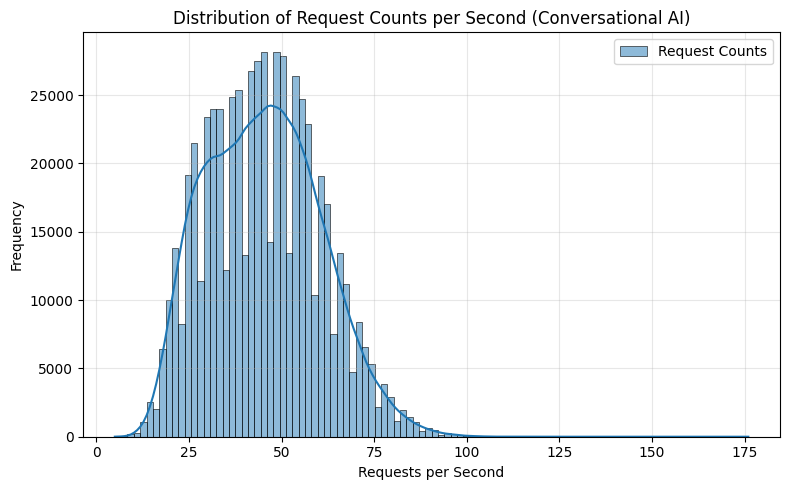

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(counts_1s, ax=ax, bins=100, kde=True, label="Request Counts")
ax.set_xlabel("Requests per Second")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Request Counts per Second (Conversational AI)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

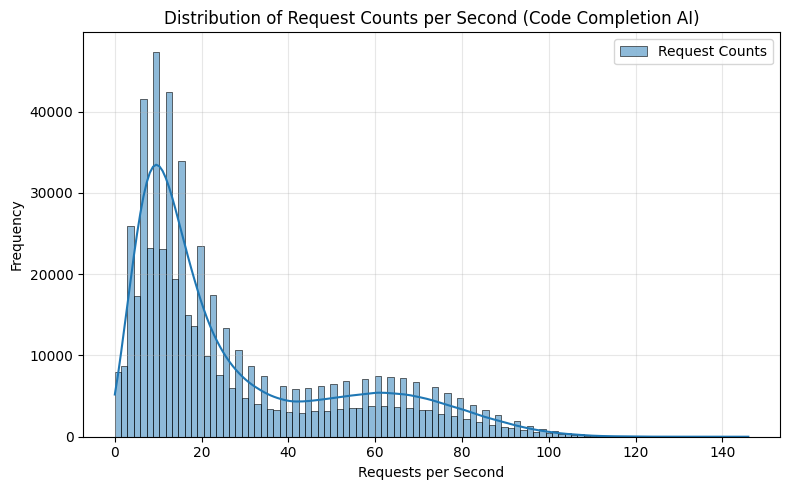

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(counts_code_1s, ax=ax, bins=100, kde=True, label="Request Counts")
ax.set_xlabel("Requests per Second")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Request Counts per Second (Code Completion AI)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

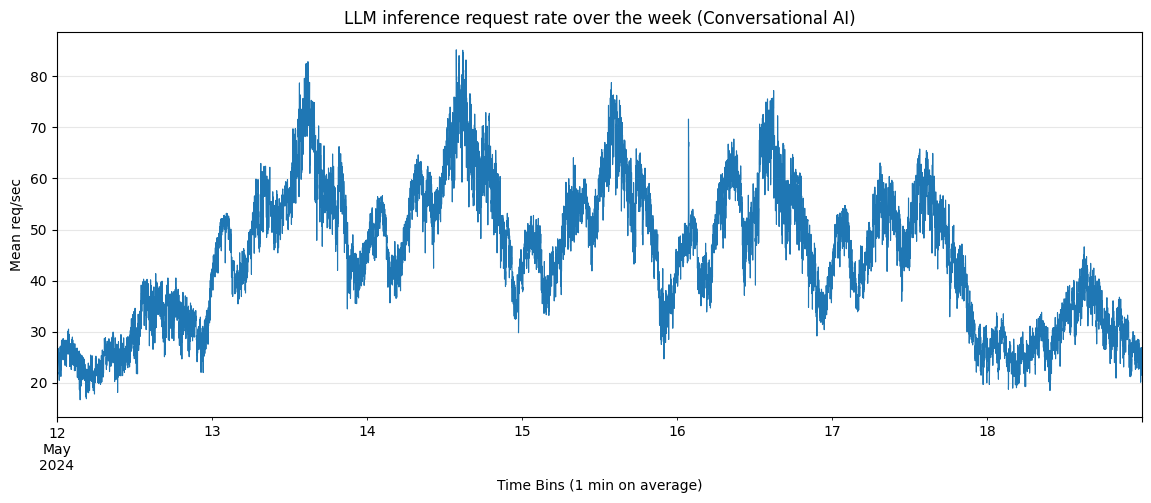

In [10]:
# aggregating the mean per minute
counts_1min = counts_1s.resample("1min").mean()

fig, ax = plt.subplots(figsize=(14, 5))
counts_1min.plot(ax=ax, linewidth=0.8)
ax.set_ylabel("Mean req/sec")
ax.set_xlabel("Time Bins (1 min on average)")
ax.set_title("LLM inference request rate over the week (Conversational AI)")
ax.grid(alpha=0.3)

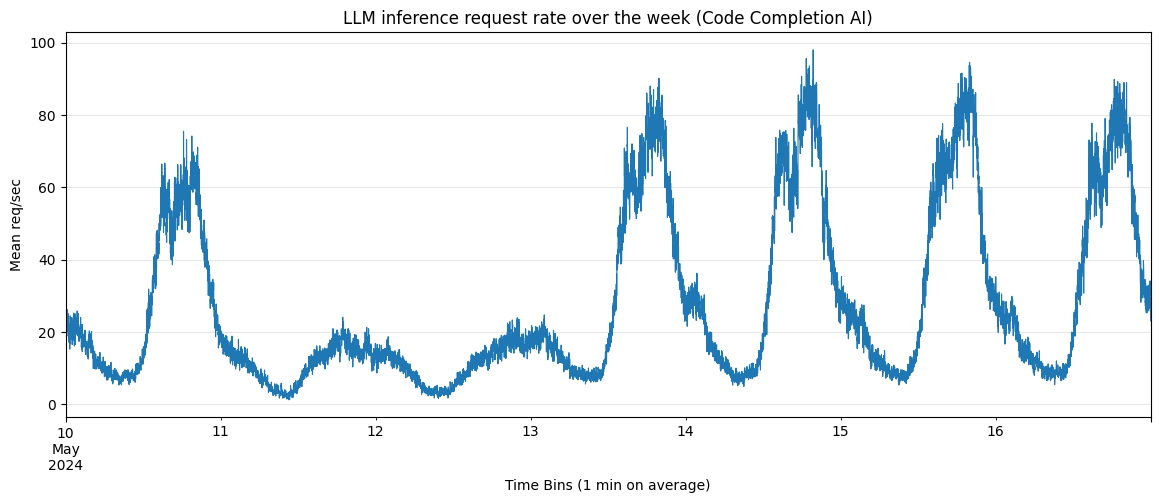

In [11]:
# aggregating the mean per minute
counts_1min = counts_code_1s.resample("1min").mean()

fig, ax = plt.subplots(figsize=(14, 5))
counts_1min.plot(ax=ax, linewidth=0.8)
ax.set_ylabel("Mean req/sec")
ax.set_xlabel("Time Bins (1 min on average)")
ax.set_title("LLM inference request rate over the week (Code Completion AI)")
ax.grid(alpha=0.3)

### EDA Review
After analyzing our datasets, we will refer to them as `code` and `conv`, we can see that `conv` has a much more even distribution, which represents more realistic activity to what we would see in a containerized high-performance compute environment.  Although `code` has some interesting attributes to it, the distribution of request counts per seconds is heavily right-skewed, which suits less intensive HPC clusters.  The bi-modal pattern that emerges is too weak for those higher-latency request events; therefore, we opt for the normal distribution when it comes to requests per second.  

In terms of our time series figures, the `min` baseline stays above 20 requests per second in `conv`; consequently, `code` trends towards zero in non-peak hours, which again represents an environment designed for contextually-aware scaling environments (short latency spikes, lower overall workload).  These patterns are not supportive for a VM that has a consistent workload applied to it, and most likely in a local VM context.

Therefore, moving forward we will only refer to the dataset of the `conv` variety and leave the `code` dataset for future training.

### Training / Testing Splits

Produce train/test/validation splits to send into our DataLoaders.

Since we both of our datasets are a 7 day recording of Azure VM LLM activity, we decided to split them based upon the days in order; therefore, `training == 4.2 days`, `validation == 1.4 day`, `testing == 1.4 days`.  That way we can insure our training is correct without generating synthetic data to test with.

In [12]:
train_split = len(counts_1s) * .6
val_or_test_split = (len(counts_1s) * .2)
train_df = counts_1s[:int(train_split)]
validation_df = counts_1s[int(train_split):int(train_split+val_or_test_split)]
test_df = counts_1s[int(train_split+val_or_test_split):]

print(len(train_df), len(validation_df), len(test_df))

362880 120960 120960


### Error and Sanity Checks

Here we will analyze the Mean Squared Error and Mean Absolute Error.

Directly after we analyze the Mean Squared Difference to see how our figures compare to the normal errors (MAE vs MSE).  After finding this lagged difference we calculate the Rolling MSE, which will help us look at the MSE for each minute on average.

After we build a `windowing` function to parse out series into usuable bigrams of series data.  We decided to select a `step of 5 minutes (300 seconds)` per window the `horizon of 10 seconds` and `a stride of 10`.

Altering these elements didn't produce much of a difference but the model performed slightly better when moving from a step of 60, to a step of 300.

We scaled our training data to prevent leakage or overlap in any way.

ForecastDataset is our loader.

In [13]:
# Sanity Checks
mse = ((train_df - train_df.mean())**2).mean()
mae = (train_df - train_df.mean()).abs().mean()
print(f"MSE: {mse:.2f}, MAE: {mae:.2f}")

persistence = ((train_df - train_df.shift(1))**2).mean()
print(f"Persistence MSE: {persistence:.2f}")
forecast = validation_df.rolling(60).mean()
rolling_mse = ((validation_df - forecast)**2).mean()
print(f"Rolling Mean MSE: {rolling_mse:.2f}")

def windowing(dataset, step=60, horizon=10, stride=1):
  dataset = np.array(dataset)
  my_new_dataset = []
  for i in range(0,len(dataset)-step-horizon,stride):
    my_new_dataset.append([dataset[i:i+step], dataset[i+step:i+step+horizon]])
  return my_new_dataset

train_mean = train_df.mean()
train_std = train_df.std()

train_scaled = (train_df - train_mean) / train_std
val_scaled = (validation_df - train_mean) / train_std
test_scaled = (test_df - train_mean) / train_std

train_windows = windowing(train_scaled, step=300, horizon=10, stride=10)
val_windows = windowing(val_scaled, step=300, horizon=10, stride=10)
test_windows = windowing(test_scaled, step=300, horizon=10, stride=10)

import torch
from torch.utils.data import Dataset, DataLoader

class ForecastDataset(Dataset):
    def __init__(self, windows):
        self.inputs = torch.tensor(np.array([w[0] for w in windows]), dtype=torch.float32)
        self.targets = torch.tensor(np.array([w[1] for w in windows]), dtype=torch.float32)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

train_loader = DataLoader(ForecastDataset(train_windows), batch_size=64, shuffle=True)
val_loader = DataLoader(ForecastDataset(val_windows), batch_size=64, shuffle=False)
test_loader = DataLoader(ForecastDataset(test_windows), batch_size=64, shuffle=False)

MSE: 242.56, MAE: 12.64
Persistence MSE: 104.35
Rolling Mean MSE: 67.54


### Training
The original thought was `LSTM` vs something with a longer attention span, since our data is large and time-series based.  Therefore, we chose a `TransformerEncoder`, which narrates the story of "parallel" vs "sequential" processing.  We are curious how the `LSTM` stands up to a seemingly superior transformer.  Since order matters for us and we're not doing any complicated randomization, then `LSTM` might emerge as a cheaper, quicker train compared to the performance gains we get from training the transformer encoder.

LSTM architecture for time-series forecasting.

We are viewing a univariate time series with request count only; in addition, we stack two layers to stack temporal features and see if complexity creates a harder train.  Before mixing in dropout, we take only the last timestep's hidden state, which was fixated to match the horizon parameter.  Afterwards, we push our data through dropout and the fully-connected layer.

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=128, num_layers=2, batch_first=True)
        self.fc = nn.Linear(128, 10)
        self.dp = nn.Dropout(0.2)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.dp(x)
        x = self.fc(x)
        return x


### LSTM Training Loop

In [15]:
import time
start = time.time()

train_losses = []
val_losses = []

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available! Using CUDA device.")
else:
    device = torch.device("cpu")
    print("GPU not available. Using CPU.")

model = LSTMModel()
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 10

print("\nStarting Training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {running_loss/len(train_loader):.4f}")

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Validation Loss: {val_loss/len(val_loader):.4f}")
    val_losses.append(val_loss / len(val_loader))
    train_losses.append(running_loss / len(train_loader))
print("\nTraining Complete!")
print(f"Training time: {(time.time() - start):1f}")
print("\nStarting Testing...")
model.eval()
test_loss = 0.0
predictions = []
actuals = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item()
        predictions.append(outputs.cpu().numpy())
        actuals.append(targets.cpu().numpy())

print(f"Test Loss: {test_loss/len(test_loader):.4f}")
print("Testing Complete!")

GPU is available! Using CUDA device.

Starting Training...
Epoch 1/10, Training Loss: 0.3485
Epoch 1/10, Validation Loss: 0.2723
Epoch 2/10, Training Loss: 0.2430
Epoch 2/10, Validation Loss: 0.2718
Epoch 3/10, Training Loss: 0.2411
Epoch 3/10, Validation Loss: 0.2684
Epoch 4/10, Training Loss: 0.2400
Epoch 4/10, Validation Loss: 0.2677
Epoch 5/10, Training Loss: 0.2393
Epoch 5/10, Validation Loss: 0.2686
Epoch 6/10, Training Loss: 0.2391
Epoch 6/10, Validation Loss: 0.2691
Epoch 7/10, Training Loss: 0.2389
Epoch 7/10, Validation Loss: 0.2678
Epoch 8/10, Training Loss: 0.2385
Epoch 8/10, Validation Loss: 0.2681
Epoch 9/10, Training Loss: 0.2383
Epoch 9/10, Validation Loss: 0.2671
Epoch 10/10, Training Loss: 0.2384
Epoch 10/10, Validation Loss: 0.2673

Training Complete!
Training time: 93.028069

Starting Testing...
Test Loss: 0.1587
Testing Complete!


### LSTM MSE and MAE

In [16]:
all_predictions = np.concatenate(predictions)
all_actuals = np.concatenate(actuals)

pred_orig = all_predictions * train_std + train_mean
actual_orig = all_actuals * train_std + train_mean

lstm_mse = ((pred_orig - actual_orig)**2).mean()
lstm_mae = (np.abs(pred_orig - actual_orig)).mean()

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"LSTM MSE: {lstm_mse:.2f}, MAE: {lstm_mae:.2f}")

Parameters: 200,458
LSTM MSE: 38.51, MAE: 4.90


In [17]:
# save file locally
torch.save(model.state_dict(), "lstm_model.pth")

### TransformerEncoder architecture for time-series forecasting.

Each scalar in the input sequence gets projected from 1 dimension up to 32 via a linear embedding (scaled by sqrt(32) to stabilize attention weights, following the original "Attention Is All You Need" convention). The embedded sequence passes through a single Transformer encoder layer where multi-head self-attention lets every timestep attend to every other timestep simultaneously unlike the LSTM which processes them sequentially. The final hidden state from the last timestep is extracted and projected through a linear layer to produce the forecast horizon (10 values).

In [18]:
import math

class TransformerModel(nn.Module):
    def __init__(
        self,
        input_size=32,
        nhead=4,
        num_of_tokens=10,
        num_of_layers=1,
        dropout=0.2
    ):
        super().__init__()
        self.embed = nn.Linear(1, input_size)
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=input_size,
            nhead=nhead,
            dim_feedforward=input_size*2,
            batch_first=True,
            dropout=dropout
        )
        self.tr = nn.TransformerEncoder(encoder_layers, num_of_layers)
        self.fc = nn.Linear(input_size, num_of_tokens)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.embed(x) * math.sqrt(self.embed.out_features)
        x = self.tr(x)
        x = x[:, -1, :]
        x = self.fc(x)
        return x


### Transformer Training Loop

In [19]:
start = time.time()

tr_train_losses = []
tr_val_losses = []

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available! Using CUDA device.")
else:
    device = torch.device("cpu")
    print("GPU not available. Using CPU.")

model = TransformerModel()
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 10

print("\nStarting Training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {running_loss/len(train_loader):.4f}")

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Validation Loss: {val_loss/len(val_loader):.4f}")
    tr_val_losses.append(val_loss / len(val_loader))
    tr_train_losses.append(running_loss / len(train_loader))
print("\nTraining Complete!")
print(f"Training time: {(time.time() - start):1f}")
print("\nStarting Testing...")
model.eval()
test_loss = 0.0
predictions = []
actuals = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item()
        predictions.append(outputs.cpu().numpy())
        actuals.append(targets.cpu().numpy())

print(f"Test Loss: {test_loss/len(test_loader):.4f}")
print("Testing Complete!")

GPU is available! Using CUDA device.

Starting Training...
Epoch 1/10, Training Loss: 0.4592
Epoch 1/10, Validation Loss: 0.2992
Epoch 2/10, Training Loss: 0.2933
Epoch 2/10, Validation Loss: 0.2903
Epoch 3/10, Training Loss: 0.2764
Epoch 3/10, Validation Loss: 0.2895
Epoch 4/10, Training Loss: 0.2692
Epoch 4/10, Validation Loss: 0.2876
Epoch 5/10, Training Loss: 0.2658
Epoch 5/10, Validation Loss: 0.2867
Epoch 6/10, Training Loss: 0.2632
Epoch 6/10, Validation Loss: 0.2871
Epoch 7/10, Training Loss: 0.2615
Epoch 7/10, Validation Loss: 0.2864
Epoch 8/10, Training Loss: 0.2601
Epoch 8/10, Validation Loss: 0.2857
Epoch 9/10, Training Loss: 0.2591
Epoch 9/10, Validation Loss: 0.2856
Epoch 10/10, Training Loss: 0.2589
Epoch 10/10, Validation Loss: 0.2855

Training Complete!
Training time: 66.504246

Starting Testing...
Test Loss: 0.1724
Testing Complete!


### Transformer MSE and MAE

In [20]:
all_predictions = np.concatenate(predictions)
all_actuals = np.concatenate(actuals)

pred_orig = all_predictions * train_std + train_mean
actual_orig = all_actuals * train_std + train_mean

transformer_mse = ((pred_orig - actual_orig)**2).mean()
transformer_mae = (np.abs(pred_orig - actual_orig)).mean()

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Transformer MSE: {transformer_mse:.2f}, MAE: {transformer_mae:.2f}")

Parameters: 8,938
Transformer MSE: 41.84, MAE: 5.12


In [21]:
# save file locally
torch.save(model.state_dict(), "transformer_model.pth")

### LSTM vs. Transformer Forecasting Training Performance (Training & Validation)

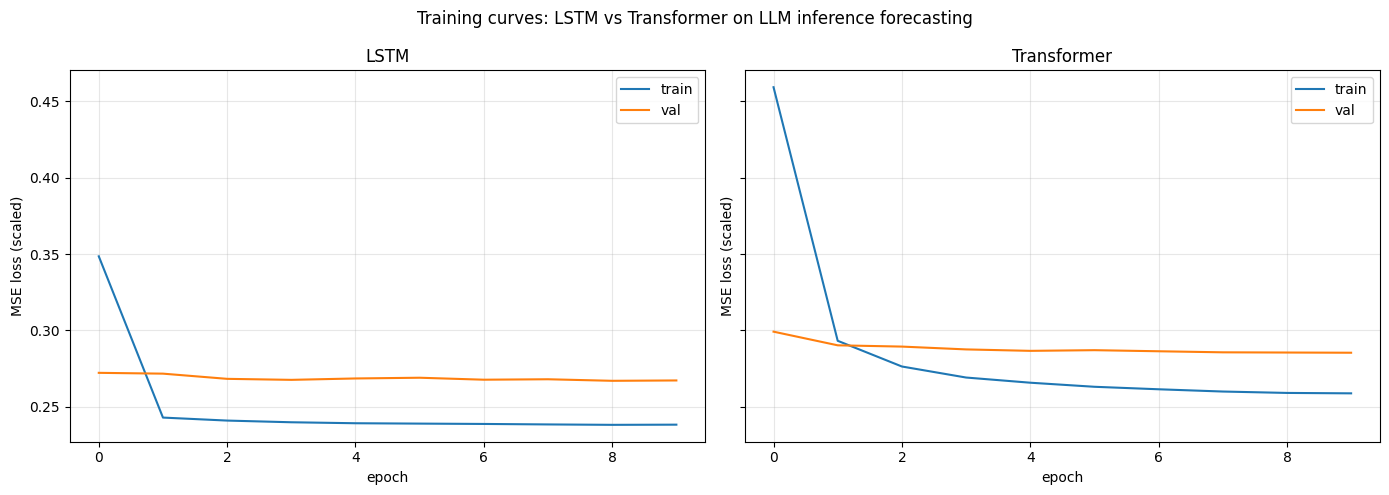

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].set_title("LSTM")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE loss (scaled)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(tr_train_losses, label="train")
axes[1].plot(tr_val_losses, label="val")
axes[1].set_title("Transformer")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("MSE loss (scaled)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training curves: LSTM vs Transformer on LLM inference forecasting")
plt.tight_layout()
plt.show()

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel()
model2 = TransformerModel()
model.load_state_dict(torch.load("./lstm_model.pth", map_location=device))
model2.load_state_dict(torch.load("./transformer_model.pth", map_location=device))
model.to(device)
model2.to(device)
model.eval()
model2.eval()


SCENARIO_LEN = 300
def make_scenario(pattern, length=SCENARIO_LEN):
    reps = (length // len(pattern)) + 1
    return (pattern * reps)[:length]

scenarios = {
    "steady_high": make_scenario([12, 14, 13, 11, 15, 13, 12, 14, 13, 15]),
    "ramp_up":     make_scenario([2]*20 + [4]*10 + [8]*10 + [12]*10 + [18]*10),
    "quiet":       make_scenario([1, 0, 1, 0, 1, 0, 1, 0, 1, 0]),
    "spike_drop":  make_scenario([3]*20 + [25]*10 + [3]*30),
    "edge_high":   [float(train_mean + 2 * train_std)] * SCENARIO_LEN,
}

results = {}
for name, raw in scenarios.items():
    scaled = ((np.array(raw) - train_mean) / train_std).astype(np.float32)
    tensor = torch.tensor(scaled).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_scaled = model(tensor).cpu().numpy()[0]
        pred_scaled_2 = model2(tensor).cpu().numpy()[0]

    pred = pred_scaled * train_std + train_mean
    pred2 = pred_scaled_2 * train_std + train_mean
    results[name] = pred
    results[name + '2'] = pred2

    print(f"\n=== {name} ===")
    print(f"  Last 10s input:  {[f'{v:.1f}' for v in raw[-10:]]}")
    print(f"  Next 10s forecast lstm: {[f'{v:.2f}' for v in pred]}")
    print(f"  Next 10s forecast transformer: {[f'{v:.2f}' for v in pred2]}")
    print(f"  Forecast mean lstm_model: {pred.mean():.2f}, max: {pred.max():.2f}")
    print(f"  Forecast mean transformer_model: {pred2.mean():.2f}, max: {pred2.max():.2f}")


=== steady_high ===
  Last 10s input:  ['12.0', '14.0', '13.0', '11.0', '15.0', '13.0', '12.0', '14.0', '13.0', '15.0']
  Next 10s forecast lstm: ['16.02', '14.95', '14.94', '14.99', '15.40', '15.34', '15.31', '15.17', '16.05', '16.07']
  Next 10s forecast transformer: ['17.66', '17.38', '17.27', '17.69', '18.36', '17.90', '17.67', '17.77', '18.72', '17.44']
  Forecast mean lstm_model: 15.42, max: 16.07
  Forecast mean transformer_model: 17.79, max: 18.72

=== ramp_up ===
  Last 10s input:  ['18.0', '18.0', '18.0', '18.0', '18.0', '18.0', '18.0', '18.0', '18.0', '18.0']
  Next 10s forecast lstm: ['18.52', '17.50', '17.58', '17.60', '17.93', '17.95', '17.84', '17.71', '18.45', '18.50']
  Next 10s forecast transformer: ['17.65', '17.36', '17.56', '17.88', '18.32', '17.81', '17.64', '17.76', '18.51', '17.63']
  Forecast mean lstm_model: 17.96, max: 18.52
  Forecast mean transformer_model: 17.81, max: 18.51

=== quiet ===
  Last 10s input:  ['1.0', '0.0', '1.0', '0.0', '1.0', '0.0', '1.0'

### Description of Auxillary Tests
* steady_high - Can the AI properly predict a steady workload, which needs a higher ceiling than a nominal execution.
* ramp_up - Does the model able to detect a VM that is ramping up in computational resources?
* quiet - Does the model detect whether the environment is running a quiet load?
* spike_drop - Does the model detect a nose-dive in a VM ramping down?
* edge_high - Can the model detect an upper-boundary edge for the sequence and predicted sequence?


### Summary

#### Objective
This module investigated whether deep learning models could forecast LLM inference request rates
from Azure VM traces.

#### Dataset Selection
We selected the conversational LLM trace over the code completion trace because the `conv` dataset provided the normal distribution over our requests per second; consequently, `code` provided a right-skewed, lightly bimodal distribution.  If most of our values live around zero, then our models will learn patterns for low-intensity high-performance compute environments, which is why we opted for the conversational dataset over code completions.

#### Baseline Performance
Before training any neural network, we established naive baselines on the training set:
- Mean predictor MSE: 242.56
- Persistence MSE: 104.35
- Rolling mean (60s window) MSE: 67.54

Any trained model must beat these to justify its complexity.

#### Model Comparison
| Metric | LSTM | Transformer |
|--------|------|-------------|
| Test MSE | 38.51 | 41.84 |
| Test MAE | 4.90 | 5.12 |
| Parameters | 200458 | 8938 |
| Training time | 93.028069s | 66.504246s |

#### Key Findings
Although our Transformer Encoder trained similarly to the outcome of our LSTM, the LSTM seems to perform better on test data (as seen above).

#### Limitations
The `code` dataset has data that doesn't help in training patterns in the LSTM/TranformerEncoder.

#### Challenges
Colab requires a subscription if you run over the free tier so we couldn't do a sweeping analysis of each step count.  However, we compared 60 to 300 steps, and the performance gain from that was nominal at best.